In [12]:
import os
from langchain.chat_models import init_chat_model
llm=init_chat_model("groq:llama3-8b-8192")
llm

ChatGroq(profile={'max_input_tokens': 8192, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x00000233DE881A90>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000233DE882710>, model_name='llama3-8b-8192', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [13]:
from typing import Annotated

from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from typing_extensions import TypedDict

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

from langgraph.types import Command, interrupt

class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

@tool
def human_assistance(query: str) -> str:
    """Request assistance from a human."""
    human_response = interrupt({"query": query})
    return human_response["data"]

tool = TavilySearch(max_results=2)
tools = [tool, human_assistance]
llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State):
    message = llm_with_tools.invoke(state["messages"])
    # Because we will be interrupting during tool execution,
    # we disable parallel tool calling to avoid repeating any
    # tool invocations when we resume.
    
    return {"messages": [message]}

graph_builder.add_node("chatbot", chatbot)

tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

In [14]:
memory = MemorySaver()

graph = graph_builder.compile(checkpointer=memory)

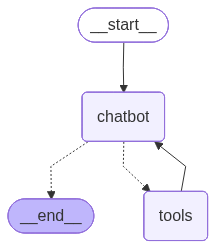

In [15]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [ ]:
from langchain.chat_models import init_chat_model
llm = init_chat_model('groq:llama-3.1-8b-instant')
llm_with_tools = llm.bind_tools(tools)

from langchain_core.messages import HumanMessage

user_input = "I need some expert guidance and assistance for building an AI agent. Could you request assistance for me?"

config = {"configurable": {"thread_id": "1"}}

events = graph.stream(
    {"messages": [HumanMessage(content=user_input)]},
    config,
    stream_mode="values",
)

for event in events:
    print(event)  # debug
    if "messages" in event:
        event["messages"][-1].pretty_print()

{'messages': [HumanMessage(content='I need some expert guidance...', additional_kwargs={}, response_metadata={}, id='80aa9bb7-fe79-47de-ac77-263a9768e4d0')]}
================================ Human Message =================================

I need some expert guidance...
{'messages': [HumanMessage(content='I need some expert guidance...', additional_kwargs={}, response_metadata={}, id='80aa9bb7-fe79-47de-ac77-263a9768e4d0'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '3my5bdgnt', 'function': {'arguments': '{"query":"expert guidance"}', 'name': 'human_assistance'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 1739, 'total_tokens': 1756, 'completion_time': 0.029095996, 'completion_tokens_details': None, 'prompt_time': 0.123400684, 'prompt_tokens_details': None, 'queue_time': 0.058726166, 'total_time': 0.15249668}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_deman

In [17]:
# Prevent a second tool-call loop after human resume
llm_with_tools = llm.bind_tools(tools, tool_choice='none')

human_response = (
    "We, the experts are here to help! We'd recommend you check out LangGraph to build your agent."
    " It's much more reliable and extensible than simple autonomous agents."
)

human_command = Command(resume={"data": human_response})

events = graph.stream(human_command, config, stream_mode="values")
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  human_assistance (3my5bdgnt)
 Call ID: 3my5bdgnt
  Args:
    query: expert guidance
================================= Tool Message =================================
Name: human_assistance

We, the experts are here to help! We'd recommend you check out LangGraph to build your agent. It's much more reliable and extensible than simple autonomous agents.


BadRequestError: Error code: 400 - {'error': {'message': "Failed to call a function. Please adjust your prompt. See 'failed_generation' for more details.", 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '<function=tavily_search>{"query": "LangGraph", "topic": "general"}'}}